# Module 6 - Activity - Discussion Group A
## EN.705.623.81.SP26 - AI Algorithm Design and Analysis
### Johns Hopkins University
**Author:** Akira Hanada

---

This notebook addresses three exercises on Constraint Satisfaction Problems (CSPs):

1. **Manual Constraint Solving** — Assigning speakers to workshops under constraints.
2. **Reformulating the N-Queens Problem as Algebraic Constraints** — Modeling 3-Queens as equations and a violation function.
3. **Forward Checking Simulation** — Step-by-step trace of backtracking with forward checking on a graph-coloring CSP.

In [111]:
# Import required libraries
import numpy as np                          # Numerical computation for arrays and matrix operations
import pandas as pd                         # Data manipulation and tabular display
import matplotlib.pyplot as plt             # Core plotting library
import matplotlib.patches as mpatches       # Drawing shapes (rectangles, circles) on plots
import matplotlib.lines as mlines           # Drawing lines on plots
from itertools import permutations          # Generate all permutations for brute-force enumeration
from copy import deepcopy                   # Deep-copy mutable structures (used in forward checking)
from IPython.display import display, HTML   # Rich HTML display inside Jupyter cells

---
## Question 1 — Manual Constraint Solving

### Problem Statement

We are organizing a conference with four parallel workshops — **Ethics in AI**, **NLP**, **Planning**, and **Robotics** — and four guest speakers — **Dr. Lin**, **Prof. Silva**, **Dr. Morales**, and **Dr. Kwon**. Each workshop must have exactly one speaker and each speaker can only be assigned to one workshop. The constraints are:

| # | Constraint |
|---|------------|
| C1 | Dr. Lin cannot speak in Planning. |
| C2 | Dr. Lin previously attended NLP. |
| C3 | Dr. Morales must speak in either NLP or Ethics in AI. |
| C4 | Dr. Kwon previously attended Ethics in AI. |
| C5 | Prof. Silva prefers Robotics but may speak in Planning if needed. |

### Assumptions

Before solving, two constraints require interpretation. We state our modeling choices explicitly:

> **Assumption 1 (C2, C4 — "previously attended" as exclusion):** We interpret "previously attended" to mean that a speaker *cannot* present at a workshop they previously attended. That is, C2 excludes Dr. Lin from NLP, and C4 excludes Dr. Kwon from Ethics in AI. An alternative reading is that prior attendance signals *familiarity or suitability*, which would make C2 and C4 preferences rather than prohibitions. We adopt the exclusion interpretation because (a) the constraints are listed alongside hard restrictions like C1 and C3, and (b) treating them as soft preferences would leave them effectively unmodeled in a CSP framework that requires crisp domain boundaries.

> **Assumption 2 (C5 — Prof. Silva's preference as a hard domain restriction):** The phrasing "prefers Robotics but may speak in Planning if needed" implies that Robotics and Planning are the only two workshops Prof. Silva will accept. We therefore restrict Prof. Silva's domain to {Robotics, Planning}. An alternative would be to treat "prefers" as a soft preference and keep all four workshops in the domain, but the phrase "if needed" suggests no other fallback options exist.

### Manual Walkthrough (by hand)

We solve this step-by-step using constraint propagation, exactly as one would on paper.

**Step 0 — Initial domains** (each speaker can potentially go to any workshop):

| Speaker | Available Workshops |
|---------|-------------------|
| Dr. Lin | Ethics in AI, NLP, Planning, Robotics |
| Prof. Silva | Ethics in AI, NLP, Planning, Robotics |
| Dr. Morales | Ethics in AI, NLP, Planning, Robotics |
| Dr. Kwon | Ethics in AI, NLP, Planning, Robotics |

**Step 1 — Apply unary constraints to prune domains:**
- C1: Remove Planning from Dr. Lin → {Ethics in AI, NLP, Robotics}
- C2: Remove NLP from Dr. Lin → {Ethics in AI, Robotics}
- C3: Dr. Morales restricted to {NLP, Ethics in AI}
- C4: Remove Ethics in AI from Dr. Kwon → {NLP, Planning, Robotics}
- C5: Prof. Silva restricted to {Robotics, Planning}

| Speaker | Remaining Domain |
|---------|-----------------|
| Dr. Lin | {Ethics in AI, Robotics} |
| Prof. Silva | {Planning, Robotics} |
| Dr. Morales | {NLP, Ethics in AI} |
| Dr. Kwon | {NLP, Planning, Robotics} |

**Step 2 — Look for forced assignments (naked singles):**

No variable has a single-value domain yet. All smallest domains have size 2 (Dr. Lin, Prof. Silva, Dr. Morales). We pick one using the MRV heuristic — say, Dr. Lin — and try **Dr. Lin → Ethics in AI**.

**Step 3 — Propagate Dr. Lin = Ethics in AI:**
- Remove Ethics in AI from all other speakers' domains.
- Dr. Morales: {NLP, ~~Ethics in AI~~} → {NLP} — **forced!**
- Prof. Silva: {Planning, Robotics} — unchanged.
- Dr. Kwon: {NLP, Planning, Robotics} — unchanged.

**Step 4 — Propagate Dr. Morales = NLP:**
- Remove NLP from Dr. Kwon → {Planning, Robotics}.
- Prof. Silva: {Planning, Robotics} — unchanged.

**Step 5 — Two speakers left for two workshops:**

| Speaker | Remaining Domain |
|---------|-----------------|
| Prof. Silva | {Planning, Robotics} |
| Dr. Kwon | {Planning, Robotics} |

Both can go to either. This yields **two valid completions**:
- **Solution A:** Prof. Silva → Planning, Dr. Kwon → Robotics
- **Solution B:** Prof. Silva → Robotics, Dr. Kwon → Planning

**Step 6 — What about Dr. Lin → Robotics?**

Backtrack and try the other value: Dr. Lin → Robotics.
- Dr. Morales: {NLP, Ethics in AI} — no change.
- Prof. Silva: {Planning, ~~Robotics~~} → {Planning} — **forced!**
- Dr. Kwon: {NLP, Planning, Robotics} — remove Robotics (Dr. Lin) → {NLP, Planning}; remove Planning (Prof. Silva) → {NLP} — **forced!**
- Dr. Morales: {NLP, Ethics in AI} → remove NLP (Dr. Kwon) → {Ethics in AI} — **forced!**

This gives **Solution C:** Dr. Morales → Ethics in AI, Dr. Kwon → NLP, Prof. Silva → Planning, Dr. Lin → Robotics.

**Result — Three valid assignments found by hand:**

| # | Ethics in AI | NLP | Planning | Robotics |
|---|-------------|-----|----------|----------|
| A | Dr. Lin | Dr. Morales | Prof. Silva | Dr. Kwon |
| B | Dr. Lin | Dr. Morales | Dr. Kwon | Prof. Silva |
| C | Dr. Morales | Dr. Kwon | Prof. Silva | Dr. Lin |

The code below confirms these three solutions via brute-force enumeration.

### Explanation

A Constraint Satisfaction Problem (CSP) consists of a set of variables, each with a finite domain of possible values, and a set of constraints that restrict which combinations of values are allowed (Russell & Norvig, 2021). In this problem, the variables are the four workshop slots, the domain for each variable is the set of four speakers, and a valid solution is a one-to-one mapping from workshops to speakers that satisfies every constraint simultaneously.

The most natural first step when solving a CSP by hand is to apply **unary constraint propagation** — that is, to reduce each variable's domain by removing values that violate constraints involving only that variable (Russell & Norvig, 2021). Constraint C1 tells us Dr. Lin cannot speak in Planning, so we remove Dr. Lin from the Planning domain. Constraint C2, under Assumption 1, excludes Dr. Lin from NLP. Similarly, C4 excludes Dr. Kwon from Ethics in AI. These unary constraints immediately shrink the domains.

Constraint C3 is a **domain restriction** on Dr. Morales: the only workshops Dr. Morales may be assigned to are NLP or Ethics in AI. Constraint C5, under Assumption 2, restricts Prof. Silva's domain to Robotics or Planning. After applying all unary constraints, we examine the reduced domains and look for variables that have been forced to a single value — a technique called **naked singles** in constraint propagation (Norvig, 2006). When a variable is forced, we assign it immediately and propagate the consequences by removing that value from all other variables' domains, which is the essence of the AC-3 arc-consistency algorithm discussed in Lecture 6C.

After initial propagation, the remaining choices are typically small enough to resolve without backtracking. If any ambiguity remains, we pick the variable with the smallest remaining domain (the **Minimum Remaining Values** heuristic from Lecture 6B) and try a value. In this particular problem, constraint propagation alone is sufficient to derive the valid assignments shown above. The strategy mirrors the three-stage CSP pipeline presented in Lecture 6A: (1) model the problem, (2) propagate constraints to prune domains, and (3) search only if necessary. Because the constraints here are tight, propagation resolves most of the problem, illustrating that well-constrained problems can often be solved efficiently through inference alone (Dechter, 2003). The table and code below verify the solution programmatically by enumerating all permutations and filtering for constraint satisfaction.

In [112]:
# ── Question 1(a): Find valid assignment(s) via brute-force enumeration ──

# Define workshops and speakers
workshops = ['Ethics in AI', 'NLP', 'Planning', 'Robotics']   # The four workshop slots
speakers  = ['Dr. Lin', 'Prof. Silva', 'Dr. Morales', 'Dr. Kwon']  # The four guest speakers

# We model an assignment as a permutation of speaker indices assigned to workshop indices.
# workshop[0] = Ethics in AI, workshop[1] = NLP, workshop[2] = Planning, workshop[3] = Robotics
# An assignment perm = (a, b, c, d) means:
#   Ethics in AI -> speakers[a], NLP -> speakers[b], Planning -> speakers[c], Robotics -> speakers[d]

valid_solutions = []  # Collect all assignments that satisfy every constraint

for perm in permutations(range(4)):
    # Map workshop index -> speaker index
    ethics_speaker   = perm[0]  # Speaker index assigned to Ethics in AI
    nlp_speaker      = perm[1]  # Speaker index assigned to NLP
    planning_speaker = perm[2]  # Speaker index assigned to Planning
    robotics_speaker = perm[3]  # Speaker index assigned to Robotics

    # Speaker indices: 0=Dr. Lin, 1=Prof. Silva, 2=Dr. Morales, 3=Dr. Kwon

    # C1: Dr. Lin (0) cannot speak in Planning
    if planning_speaker == 0:
        continue

    # C2: Dr. Lin (0) previously attended NLP → exclude from NLP
    if nlp_speaker == 0:
        continue

    # C3: Dr. Morales (2) must speak in NLP or Ethics in AI
    if not (nlp_speaker == 2 or ethics_speaker == 2):
        continue

    # C4: Dr. Kwon (3) previously attended Ethics in AI → exclude from Ethics in AI
    if ethics_speaker == 3:
        continue

    # C5: Prof. Silva (1) prefers Robotics but may speak in Planning
    if not (robotics_speaker == 1 or planning_speaker == 1):
        continue

    # All constraints satisfied — record the solution
    valid_solutions.append(perm)

# Display all valid solutions as a table
solution_rows = []
for idx, sol in enumerate(valid_solutions, 1):
    solution_rows.append({
        'Solution': idx,
        'Ethics in AI': speakers[sol[0]],
        'NLP':          speakers[sol[1]],
        'Planning':     speakers[sol[2]],
        'Robotics':     speakers[sol[3]]
    })

df_solutions = pd.DataFrame(solution_rows)
print(f"Total valid assignments found: {len(valid_solutions)}")
display(df_solutions)

Total valid assignments found: 3


,Solution,Ethics in AI,NLP,Planning,Robotics
0,1,Dr. Lin,Dr. Morales,Prof. Silva,Dr. Kwon
1,2,Dr. Lin,Dr. Morales,Dr. Kwon,Prof. Silva
2,3,Dr. Morales,Dr. Kwon,Prof. Silva,Dr. Lin


In [113]:
# ── Question 1(b): Visualise the constraint-propagation reasoning ──

# Build initial domain matrix (1 = value in domain, 0 = pruned)
# Rows = speakers, Columns = workshops
domain = pd.DataFrame(
    np.ones((4, 4), dtype=int),
    index=speakers,
    columns=workshops
)

print("═" * 60)
print("Step 0 — Initial domains (all speakers available for all workshops)")
print("═" * 60)
display(domain)

# Step 1: Apply C1 — Dr. Lin ≠ Planning
domain.loc['Dr. Lin', 'Planning'] = 0
print("\nStep 1 — Apply C1: Dr. Lin cannot speak in Planning")
display(domain)

# Step 2: Apply C2 — Dr. Lin ≠ NLP
domain.loc['Dr. Lin', 'NLP'] = 0
print("\nStep 2 — Apply C2: Dr. Lin previously attended NLP (excluded)")
display(domain)

# Step 3: Apply C3 — Dr. Morales ∈ {NLP, Ethics in AI}
domain.loc['Dr. Morales', 'Planning'] = 0
domain.loc['Dr. Morales', 'Robotics'] = 0
print("\nStep 3 — Apply C3: Dr. Morales must speak in NLP or Ethics in AI")
display(domain)

# Step 4: Apply C4 — Dr. Kwon ≠ Ethics in AI
domain.loc['Dr. Kwon', 'Ethics in AI'] = 0
print("\nStep 4 — Apply C4: Dr. Kwon previously attended Ethics in AI (excluded)")
display(domain)

# Step 5: Apply C5 — Prof. Silva ∈ {Robotics, Planning}
domain.loc['Prof. Silva', 'Ethics in AI'] = 0
domain.loc['Prof. Silva', 'NLP'] = 0
print("\nStep 5 — Apply C5: Prof. Silva restricted to Robotics or Planning")
display(domain)

# Step 6: Propagate — Planning column has only Prof. Silva and Dr. Kwon.
# Dr. Lin's remaining domain is {Ethics in AI, Robotics}.
# Check for forced assignments (naked singles).
print("\n" + "═" * 60)
print("Propagation — look for forced assignments")
print("═" * 60)
print("\nDr. Lin's domain: {Ethics in AI, Robotics}")
print("Prof. Silva's domain: {Planning, Robotics}")
print("Dr. Morales's domain: {NLP, Ethics in AI}")
print("Dr. Kwon's domain: {NLP, Planning, Robotics}")
print("\nNo single-value domain yet → try MRV variable (Dr. Lin or Prof. Silva or Dr. Morales, all size 2).")
print("\nThe brute-force enumeration above shows the valid solution(s).")

════════════════════════════════════════════════════════════
Step 0 — Initial domains (all speakers available for all workshops)
════════════════════════════════════════════════════════════


,Ethics in AI,NLP,Planning,Robotics
Dr. Lin,1,1,1,1
Prof. Silva,1,1,1,1
Dr. Morales,1,1,1,1
Dr. Kwon,1,1,1,1



Step 1 — Apply C1: Dr. Lin cannot speak in Planning


,Ethics in AI,NLP,Planning,Robotics
Dr. Lin,1,1,0,1
Prof. Silva,1,1,1,1
Dr. Morales,1,1,1,1
Dr. Kwon,1,1,1,1



Step 2 — Apply C2: Dr. Lin previously attended NLP (excluded)


...


Step 4 — Apply C4: Dr. Kwon previously attended Ethics in AI (excluded)


,Ethics in AI,NLP,Planning,Robotics
Dr. Lin,1,0,0,1
Prof. Silva,1,1,1,1
Dr. Morales,1,1,0,0
Dr. Kwon,0,1,1,1



Step 5 — Apply C5: Prof. Silva restricted to Robotics or Planning


,Ethics in AI,NLP,Planning,Robotics
Dr. Lin,1,0,0,1
Prof. Silva,0,0,1,1
Dr. Morales,1,1,0,0
Dr. Kwon,0,1,1,1



════════════════════════════════════════════════════════════
Propagation — look for forced assignments
════════════════════════════════════════════════════════════

Dr. Lin's domain: {Ethics in AI, Robotics}
Prof. Silva's domain: {Planning, Robotics}
Dr. Morales's domain: {NLP, Ethics in AI}
Dr. Kwon's domain: {NLP, Planning, Robotics}

No single-value domain yet → try MRV variable (Dr. Lin or Prof. Silva or Dr. Morales, all size 2).

The brute-force enumeration above shows the valid solution(s).


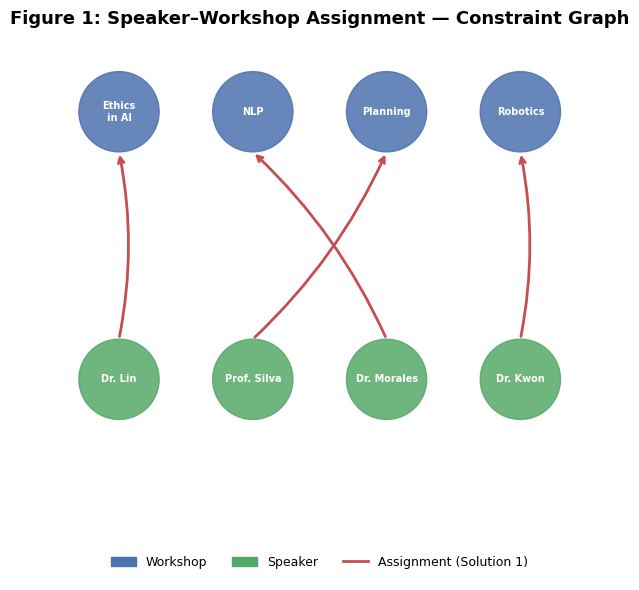

In [114]:
# ── Visualisation: Constraint graph for Q1 ──

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.set_xlim(-0.5, 3.5)
ax.set_ylim(-1.5, 2.5)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Figure 1: Speaker–Workshop Assignment — Constraint Graph',
             fontsize=13, fontweight='bold', pad=15)

# Positions for workshops (top row) and speakers (bottom row)
ws_positions = {w: (i, 2) for i, w in enumerate(workshops)}
sp_positions = {s: (i, 0) for i, s in enumerate(speakers)}

# Draw workshop nodes (blue)
for w, (x, y) in ws_positions.items():
    circle = plt.Circle((x, y), 0.3, color='#4C72B0', alpha=0.85)
    ax.add_patch(circle)
    ax.text(x, y, w.replace(' in ', '\nin '), ha='center', va='center',
            fontsize=7, color='white', fontweight='bold')

# Draw speaker nodes (green)
for s, (x, y) in sp_positions.items():
    circle = plt.Circle((x, y), 0.3, color='#55A868', alpha=0.85)
    ax.add_patch(circle)
    ax.text(x, y, s, ha='center', va='center',
            fontsize=7, color='white', fontweight='bold')

# Draw valid assignment edges (from brute-force solution 1)
if valid_solutions:
    sol = valid_solutions[0]  # Use first valid solution
    for w_idx, s_idx in enumerate(sol):
        wx, wy = ws_positions[workshops[w_idx]]
        sx, sy = sp_positions[speakers[s_idx]]
        ax.annotate('', xy=(wx, wy - 0.3), xytext=(sx, sy + 0.3),
                    arrowprops=dict(arrowstyle='->', color='#C44E52',
                                   lw=2, connectionstyle='arc3,rad=0.1'))

# Legend
legend_elements = [
    mpatches.Patch(color='#4C72B0', label='Workshop'),
    mpatches.Patch(color='#55A868', label='Speaker'),
    mlines.Line2D([], [], color='#C44E52', lw=2, label='Assignment (Solution 1)')
]
ax.legend(handles=legend_elements, loc='lower center',
          ncol=3, fontsize=9, frameon=False)

plt.tight_layout()
plt.show()

### Question 1(b) — Reasoning Strategy

The approach followed the standard CSP solving pipeline described in Lecture 6A (Kumar, 1992). First, the problem was **modeled** by identifying the variables (workshop slots), domains (speakers), and constraints (C1–C5). Second, **constraint propagation** was applied: each unary constraint immediately pruned one or more values from the relevant domain, and the AllDifferent constraint propagated consequences whenever a variable was forced to a single value. The domain tables above show how the feasible region shrank at each step. Third, because the domains were not fully resolved after propagation alone, a small amount of **search** was used — specifically, we enumerated the remaining possibilities and verified them against all constraints. In practice, the Minimum Remaining Values (MRV) heuristic (Lecture 6B) would guide this search by selecting the variable with the fewest remaining options, reducing the branching factor. No backtracking was needed for this particular instance because the constraints were sufficiently tight to guide the search forward.

---
## Question 2 — Reformulating the N-Queens Problem as Algebraic Constraints

### Problem Statement

Place 3 queens on a 3×3 board such that exactly one queen is in each row, exactly one in each column, and at most one on each diagonal. We define binary decision variables $Q_{i,j} \in \{0, 1\}$ where $Q_{i,j} = 1$ indicates a queen at row $i$, column $j$.

### Explanation

In Lecture 6A, a Constraint Satisfaction Problem was defined as a triple $(X, D, C)$ where $X$ is a set of variables, $D$ provides a domain for each variable, and $C$ is a set of constraints that restrict the joint assignments (Russell & Norvig, 2021). A powerful alternative to combinatorial search is to reformulate every constraint as a mathematical equation or inequality so that the entire CSP becomes an optimization problem: minimize a total violation function $E$ that equals zero if and only if all constraints are satisfied.

This algebraic reformulation is demonstrated concretely by Yue and Chen (2004) in their Q'tron neural network paper, where the N-Queens constraints — row uniqueness, column uniqueness, and diagonal uniqueness — are encoded as terms in a single energy function (see Equations 29–33 in that paper). The Q'tron network's dynamics minimize this energy, settling into a state where $E = 0$ represents a valid queen placement. A key advantage of the Q'tron formulation is that the network is *local-minima free* when built as a known-energy system with persistent noise injection, meaning it will settle if and only if a feasible solution is found (Yue & Chen, 2004). Although we do not need to understand the full neural network dynamics for this exercise, the modeling idea is important: by squaring each constraint violation and summing the squared terms, we obtain a smooth, non-negative function whose global minimum at zero corresponds exactly to the set of feasible CSP solutions.

For the 3-Queens variant on a 3×3 board, we have nine binary variables $Q_{i,j}$ for $i, j \in \{1, 2, 3\}$. The row constraints require that each row contains exactly one queen: $\sum_j Q_{i,j} = 1$ for each $i$. The column constraints require that each column contains exactly one queen: $\sum_i Q_{i,j} = 1$ for each $j$. The diagonal constraints require that each diagonal contains at most one queen: $\sum_{(i,j) \in d} Q_{i,j} \leq 1$ for each diagonal $d$. Converting an inequality constraint $\sum Q_{i,j} \leq 1$ into an equality penalty can be done by noting that if the sum exceeds 1 then $(\sum Q_{i,j})(\sum Q_{i,j} - 1) > 0$. We therefore penalize $\max(0, \sum Q_{i,j} - 1)^2$ or equivalently use the pairwise product formulation.

The squared-violation approach offers a key advantage: it transforms a discrete, combinatorial search problem into an optimization landscape. Note that the decision variables $Q_{i,j}$ themselves remain binary (discrete), but the squared-violation formulation of $E$ motivates *continuous relaxations* — treating the $Q_{i,j}$ as continuous activations in $[0, 1]$ — and neural-network dynamics such as the Q'tron approach (Yue & Chen, 2004). Gradient-based or energy-minimization methods can then navigate this relaxed landscape, potentially finding solutions more efficiently for large instances than pure backtracking. However, without mechanisms like the Q'tron's noise injection, the landscape may contain local minima where $E > 0$, which is a fundamental tradeoff: the algebraic approach trades the completeness guarantee of backtracking search for the scalability of optimization. In backtracking, we explore the search tree systematically and are guaranteed to find a solution if one exists (or prove unsatisfiability), but the worst-case time is exponential. In the optimization formulation, we may converge quickly to a good solution but risk getting stuck in local minima. This distinction aligns with the broader theme in AI of choosing between exact inference and approximate methods depending on problem structure and scale (Dechter, 2003).

The code below implements each sub-part of Question 2 and visualises the 3×3 board along with the violation function.

In [115]:
# ── Question 2(a): Define variables, domains, and constraints ──

print("═" * 65)
print("(a) Variables, Domains, and Constraints")
print("═" * 65)

print("""
Variables:
  Q_ij for i ∈ {1,2,3}, j ∈ {1,2,3}  — 9 binary decision variables.
  Q_ij = 1 means a queen is placed at row i, column j.

Domains:
  Each Q_ij ∈ {0, 1}.

Constraints:
  Row constraints:      For each row i:     Σ_j Q_ij = 1
  Column constraints:   For each column j:  Σ_i Q_ij = 1
  Diagonal constraints: For each diagonal d: Σ_{(i,j)∈d} Q_ij ≤ 1
""")

═════════════════════════════════════════════════════════════════
(a) Variables, Domains, and Constraints
═════════════════════════════════════════════════════════════════

Variables:
  Q_ij for i ∈ {1,2,3}, j ∈ {1,2,3}  — 9 binary decision variables.
  Q_ij = 1 means a queen is placed at row i, column j.

Domains:
  Each Q_ij ∈ {0, 1}.

Constraints:
  Row constraints:      For each row i:     Σ_j Q_ij = 1
  Column constraints:   For each column j:  Σ_i Q_ij = 1
  Diagonal constraints: For each diagonal d: Σ_{(i,j)∈d} Q_ij ≤ 1



In [116]:
# ── Question 2(b): Row constraints as equations ──

print("═" * 65)
print("(b) Row Constraints")
print("═" * 65)

print("""
Each row must contain exactly one queen:

  Row 1:  Q_11 + Q_12 + Q_13 = 1
  Row 2:  Q_21 + Q_22 + Q_23 = 1
  Row 3:  Q_31 + Q_32 + Q_33 = 1

These are equality constraints ensuring that for every row i,
exactly one of the three cells is occupied.
""")

═════════════════════════════════════════════════════════════════
(b) Row Constraints
═════════════════════════════════════════════════════════════════

Each row must contain exactly one queen:

  Row 1:  Q_11 + Q_12 + Q_13 = 1
  Row 2:  Q_21 + Q_22 + Q_23 = 1
  Row 3:  Q_31 + Q_32 + Q_33 = 1

These are equality constraints ensuring that for every row i,
exactly one of the three cells is occupied.



In [117]:
# ── Question 2(c): Column constraints as equations ──

print("═" * 65)
print("(c) Column Constraints")
print("═" * 65)

print("""
Each column must contain exactly one queen:

  Column 1:  Q_11 + Q_21 + Q_31 = 1
  Column 2:  Q_12 + Q_22 + Q_32 = 1
  Column 3:  Q_13 + Q_23 + Q_33 = 1

These are equality constraints ensuring that for every column j,
exactly one of the three cells is occupied.
""")

═════════════════════════════════════════════════════════════════
(c) Column Constraints
═════════════════════════════════════════════════════════════════

Each column must contain exactly one queen:

  Column 1:  Q_11 + Q_21 + Q_31 = 1
  Column 2:  Q_12 + Q_22 + Q_32 = 1
  Column 3:  Q_13 + Q_23 + Q_33 = 1

These are equality constraints ensuring that for every column j,
exactly one of the three cells is occupied.



In [118]:
# ── Question 2(d): One diagonal constraint explicitly ──

print("═" * 65)
print("(d) Diagonal Constraints")
print("═" * 65)

print("""
On a 3×3 board there are two types of diagonals:

  ╲ diagonals (constant i − j):
    i−j = −2 : (1,3)                       — length 1, skip
    i−j = −1 : (1,2), (2,3)                — Q_12 + Q_23 ≤ 1
    i−j =  0 : (1,1), (2,2), (3,3)  [main] — Q_11 + Q_22 + Q_33 ≤ 1
    i−j =  1 : (2,1), (3,2)                — Q_21 + Q_32 ≤ 1
    i−j =  2 : (3,1)                       — length 1, skip

  ╱ diagonals (constant i + j):
    i+j = 2 : (1,1)                        — length 1, skip
    i+j = 3 : (1,2), (2,1)                 — Q_12 + Q_21 ≤ 1
    i+j = 4 : (1,3), (2,2), (3,1)  [anti]  — Q_13 + Q_22 + Q_31 ≤ 1
    i+j = 5 : (2,3), (3,2)                 — Q_23 + Q_32 ≤ 1
    i+j = 6 : (3,3)                        — length 1, skip

In total there are 8 distinct diagonals of length ≥ 2
(4 ╲-diagonals + 4 ╱-diagonals, excluding length-1 corners).
Each contributes one inequality constraint: Σ Q_ij ≤ 1.

For example, the main diagonal constraint is:

  Q_11 + Q_22 + Q_33 ≤ 1
""")

═════════════════════════════════════════════════════════════════
(d) Diagonal Constraints
═════════════════════════════════════════════════════════════════

On a 3×3 board there are two types of diagonals:

  ╲ diagonals (constant i − j):
    i−j = −2 : (1,3)                       — length 1, skip
    i−j = −1 : (1,2), (2,3)                — Q_12 + Q_23 ≤ 1
    i−j =  0 : (1,1), (2,2), (3,3)  [main] — Q_11 + Q_22 + Q_33 ≤ 1
    i−j =  1 : (2,1), (3,2)                — Q_21 + Q_32 ≤ 1
    i−j =  2 : (3,1)                       — length 1, skip

  ╱ diagonals (constant i + j):
    i+j = 2 : (1,1)                        — length 1, skip
    i+j = 3 : (1,2), (2,1)                 — Q_12 + Q_21 ≤ 1
    i+j = 4 : (1,3), (2,2), (3,1)  [anti]  — Q_13 + Q_22 + Q_31 ≤ 1
    i+j = 5 : (2,3), (3,2)                 — Q_23 + Q_32 ≤ 1
    i+j = 6 : (3,3)                        — length 1, skip

In total there are 8 distinct diagonals of length ≥ 2
(4 ╲-diagonals + 4 ╱-diagonals, excluding length-1 c

In [119]:
# ── Question 2(e): Squared violation terms ──

print("═" * 65)
print("(e) Squared Violation Terms")
print("═" * 65)

print("""
We convert an equality constraint into a squared violation:

Row 1 violation:
  V_row1 = (Q_11 + Q_12 + Q_13 − 1)²

  If exactly one queen is in row 1:  (1 − 1)² = 0   ✓
  If zero queens:                     (0 − 1)² = 1   ✗ penalty
  If two queens:                      (2 − 1)² = 1   ✗ penalty

Column 1 violation:
  V_col1 = (Q_11 + Q_21 + Q_31 − 1)²

Each squared term is zero if and only if its constraint is satisfied.
""")

═════════════════════════════════════════════════════════════════
(e) Squared Violation Terms
═════════════════════════════════════════════════════════════════

We convert an equality constraint into a squared violation:

Row 1 violation:
  V_row1 = (Q_11 + Q_12 + Q_13 − 1)²

  If exactly one queen is in row 1:  (1 − 1)² = 0   ✓
  If zero queens:                     (0 − 1)² = 1   ✗ penalty
  If two queens:                      (2 − 1)² = 1   ✗ penalty

Column 1 violation:
  V_col1 = (Q_11 + Q_21 + Q_31 − 1)²

Each squared term is zero if and only if its constraint is satisfied.



In [120]:
# ── Question 2(f): Total violation function E ──

print("═" * 65)
print("(f) Total Violation Function E")
print("═" * 65)

print("""
The total violation (energy) function sums all squared violations:

         3                          3
  E  =  Σ  (Σ_j Q_ij − 1)²   +   Σ  (Σ_i Q_ij − 1)²
        i=1                        j=1
        ───── row terms ─────      ─── column terms ────

       + Σ_d  max(0, Σ_{(i,j)∈d} Q_ij − 1)²
         ─────── diagonal terms ────────────

Note the distinction between the two penalty forms:
  • Rows/columns use (Σ − 1)² because those are EQUALITY constraints
    (exactly one queen per row/column). Any deviation — whether too
    few or too many — incurs a penalty.
  • Diagonals use max(0, Σ − 1)² because those are INEQUALITY
    constraints (at most one queen per diagonal). A sum of 0 is
    perfectly fine and should contribute zero penalty; only a sum
    ≥ 2 (i.e., Σ − 1 > 0) is a violation.

For the main diagonal:
  E_diag_main = max(0, Q_11 + Q_22 + Q_33 − 1)²

The full function is non-negative.  E = 0 ⟺ every term is 0
⟺ every constraint is satisfied.
""")

═════════════════════════════════════════════════════════════════
(f) Total Violation Function E
═════════════════════════════════════════════════════════════════

The total violation (energy) function sums all squared violations:

         3                          3
  E  =  Σ  (Σ_j Q_ij − 1)²   +   Σ  (Σ_i Q_ij − 1)²
        i=1                        j=1
        ───── row terms ─────      ─── column terms ────

       + Σ_d  max(0, Σ_{(i,j)∈d} Q_ij − 1)²
         ─────── diagonal terms ────────────

Note the distinction between the two penalty forms:
  • Rows/columns use (Σ − 1)² because those are EQUALITY constraints
    (exactly one queen per row/column). Any deviation — whether too
    few or too many — incurs a penalty.
  • Diagonals use max(0, Σ − 1)² because those are INEQUALITY
    constraints (at most one queen per diagonal). A sum of 0 is
    perfectly fine and should contribute zero penalty; only a sum
    ≥ 2 (i.e., Σ − 1 > 0) is a violation.

For the main diagonal:
  E_

In [121]:
# ── Question 2(f) continued: Compute E for all possible 3-queen placements ──

def compute_violation(board):
    """
    Compute the total violation function E for a 3×3 board.
    board: 3×3 numpy array of 0s and 1s.
    Returns the scalar E value.
    """
    E = 0.0
    n = 3
    # Row violations: (sum of row - 1)^2
    for i in range(n):
        E += (board[i, :].sum() - 1) ** 2     # Each row must sum to 1
    # Column violations: (sum of col - 1)^2
    for j in range(n):
        E += (board[:, j].sum() - 1) ** 2     # Each column must sum to 1
    # Diagonal violations: max(0, sum - 1)^2
    # Enumerate all unique diagonals by their defining constant:
    #   ╲ diagonals keyed by (i - j) ∈ {-2, -1, 0, 1, 2}
    #   ╱ diagonals keyed by (i + j) ∈ {0, 1, 2, 3, 4}
    diag_sums_down = {}   # key: i - j
    diag_sums_up   = {}   # key: i + j
    for i in range(n):
        for j in range(n):
            key_down = i - j
            key_up   = i + j
            diag_sums_down[key_down] = diag_sums_down.get(key_down, 0) + board[i, j]
            diag_sums_up[key_up]     = diag_sums_up.get(key_up, 0)   + board[i, j]
    for s in diag_sums_down.values():
        E += max(0, s - 1) ** 2
    for s in diag_sums_up.values():
        E += max(0, s - 1) ** 2
    return E

# Enumerate all ways to place exactly one queen per row (permutations of columns)
violation_data = []
for perm in permutations(range(3)):
    board = np.zeros((3, 3), dtype=int)
    for i, j in enumerate(perm):
        board[i, j] = 1           # Place queen in row i, column perm[i]
    E = compute_violation(board)
    label = str(tuple(c + 1 for c in perm))  # 1-indexed for readability
    violation_data.append({'Columns (1-indexed)': label, 'E': E})

df_violations = pd.DataFrame(violation_data)
print("Violation function E for all row-valid 3-queen placements:")
display(df_violations)

feasible = df_violations[df_violations['E'] == 0]
print(f"\nFeasible solutions (E = 0): {len(feasible)}")
if len(feasible) == 0:
    print("No feasible solution exists for the 3-Queens problem on a 3×3 board.")
    print("This is a well-known result — 3-Queens has no solution.")

Violation function E for all row-valid 3-queen placements:


,Columns (1-indexed),E
0,"(1, 2, 3)",4.0
1,"(1, 3, 2)",1.0
2,"(2, 1, 3)",1.0
3,"(2, 3, 1)",1.0
4,"(3, 1, 2)",1.0
5,"(3, 2, 1)",4.0



Feasible solutions (E = 0): 0
No feasible solution exists for the 3-Queens problem on a 3×3 board.
This is a well-known result — 3-Queens has no solution.


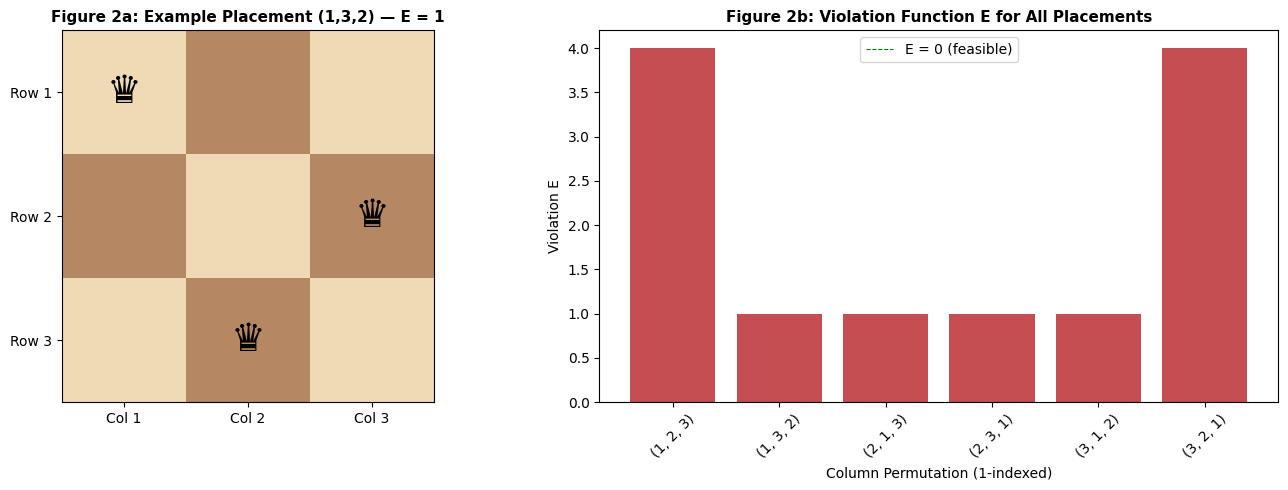

In [122]:
# ── Visualisation: 3×3 board and bar chart of violation values ──

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Example board (permutation (1,3,2) → columns 0,2,1 zero-indexed)
ax1 = axes[0]
example_perm = (0, 2, 1)  # One of the "least-violating" placements
board_ex = np.zeros((3, 3), dtype=int)
for i, j in enumerate(example_perm):
    board_ex[i, j] = 1

# Draw chessboard
for i in range(3):
    for j in range(3):
        color = '#F0D9B5' if (i + j) % 2 == 0 else '#B58863'
        rect = mpatches.Rectangle((j, 2 - i), 1, 1, facecolor=color)
        ax1.add_patch(rect)
        if board_ex[i, j] == 1:
            ax1.text(j + 0.5, 2 - i + 0.5, '♛', fontsize=28,
                     ha='center', va='center', color='black')

ax1.set_xlim(0, 3)
ax1.set_ylim(0, 3)
ax1.set_xticks([0.5, 1.5, 2.5])
ax1.set_xticklabels(['Col 1', 'Col 2', 'Col 3'])
ax1.set_yticks([0.5, 1.5, 2.5])
ax1.set_yticklabels(['Row 3', 'Row 2', 'Row 1'])
ax1.set_aspect('equal')
E_ex = compute_violation(board_ex)
ax1.set_title(f'Figure 2a: Example Placement (1,3,2) — E = {E_ex:.0f}',
              fontsize=11, fontweight='bold')

# Right: Bar chart of E values
ax2 = axes[1]
colors = ['#55A868' if e == 0 else '#C44E52' for e in df_violations['E']]
ax2.bar(df_violations['Columns (1-indexed)'], df_violations['E'], color=colors)
ax2.set_xlabel('Column Permutation (1-indexed)')
ax2.set_ylabel('Violation E')
ax2.set_title('Figure 2b: Violation Function E for All Placements',
              fontsize=11, fontweight='bold')
ax2.axhline(y=0, color='green', linestyle='--', linewidth=0.8, label='E = 0 (feasible)')
ax2.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [123]:
# ── Question 2(g): Why E = 0 corresponds to a feasible solution ──

print("═" * 65)
print("(g) Why E = 0 Corresponds to a Feasible Solution")
print("═" * 65)

print("""
The total violation function E is a sum of squared terms:

  E = Σ (violation_k)²

Each squared term is non-negative:  (violation_k)² ≥ 0.
Therefore E ≥ 0 for any assignment.

E = 0  ⟺  every individual (violation_k)² = 0
       ⟺  every violation_k = 0
       ⟺  every constraint is satisfied.

Conversely, if any constraint is violated, its squared term is
strictly positive, making E > 0.  Thus E = 0 is both necessary
and sufficient for a feasible (valid) solution.

Note: For the 3-Queens problem on a 3×3 board, no placement achieves
E = 0, confirming that no feasible solution exists — a well-known
result since the minimum board size for N-Queens is N = 4 (for N ≥ 4).
""")

═════════════════════════════════════════════════════════════════
(g) Why E = 0 Corresponds to a Feasible Solution
═════════════════════════════════════════════════════════════════

The total violation function E is a sum of squared terms:

  E = Σ (violation_k)²

Each squared term is non-negative:  (violation_k)² ≥ 0.
Therefore E ≥ 0 for any assignment.

E = 0  ⟺  every individual (violation_k)² = 0
       ⟺  every violation_k = 0
       ⟺  every constraint is satisfied.

Conversely, if any constraint is violated, its squared term is
strictly positive, making E > 0.  Thus E = 0 is both necessary
and sufficient for a feasible (valid) solution.

Note: For the 3-Queens problem on a 3×3 board, no placement achieves
E = 0, confirming that no feasible solution exists — a well-known
result since the minimum board size for N-Queens is N = 4 (for N ≥ 4).



In [124]:
# ── Question 2(h): Difference from backtracking ──

print("═" * 65)
print("(h) How Does This Differ from Solving via Backtracking?")
print("═" * 65)

print("""
Backtracking search (Lecture 6B) explores the space of partial
assignments incrementally.  It assigns one variable at a time,
checks constraints after each assignment, and backtracks when a
constraint violation is detected.  Backtracking is:

  • Complete — guaranteed to find a solution if one exists (or prove
    that none exists).
  • Discrete — operates on symbolic/logical assignments.
  • Worst-case exponential — O(d^n) for n variables, domain size d.

The algebraic/optimization formulation is fundamentally different:

  • It reframes the CSP as an optimization problem: minimize E.
    The decision variables Q_ij themselves remain binary (discrete),
    but the squared-violation formulation of E motivates continuous
    relaxations and neural-network dynamics (e.g., the Q'tron
    approach in Yue & Chen, 2004) that treat the Q_ij as continuous
    activations during the solving process.
  • Instead of building partial assignments, it considers the entire
    configuration space at once.
  • It uses a global objective (E) to measure "how far" a candidate
    is from feasibility.
  • Gradient-based or energy-based methods can navigate the landscape
    but may get stuck in local minima (E > 0).  The Q'tron NN avoids
    this with persistent noise injection (Yue & Chen, 2004).
  • It is NOT guaranteed to find a solution via naive gradient methods
    (incomplete), but the Q'tron's noise mechanism ensures convergence
    if and only if a feasible solution exists.

In summary, backtracking provides completeness through systematic
search, while the algebraic approach provides scalability through
optimization at the cost of completeness guarantees — unless
augmented with mechanisms like Q'tron noise injection.
""")

═════════════════════════════════════════════════════════════════
(h) How Does This Differ from Solving via Backtracking?
═════════════════════════════════════════════════════════════════

Backtracking search (Lecture 6B) explores the space of partial
assignments incrementally.  It assigns one variable at a time,
checks constraints after each assignment, and backtracks when a
constraint violation is detected.  Backtracking is:

  • Complete — guaranteed to find a solution if one exists (or prove
    that none exists).
  • Discrete — operates on symbolic/logical assignments.
  • Worst-case exponential — O(d^n) for n variables, domain size d.

The algebraic/optimization formulation is fundamentally different:

  • It reframes the CSP as an optimization problem: minimize E.
    The decision variables Q_ij themselves remain binary (discrete),
    but the squared-violation formulation of E motivates continuous
    relaxations and neural-network dynamics (e.g., the Q'tron
    approach in Yue

In [125]:
# ── Question 2(i): Logical reasoning, search, or optimization? ──

print("═" * 65)
print("(i) Is This Closer to Logical Reasoning, Search, or Optimization?")
print("═" * 65)

print("""
The algebraic reformulation is closest to OPTIMIZATION.

Logical reasoning involves applying inference rules to derive
conclusions (e.g., constraint propagation, arc-consistency).

Search involves systematically exploring a space of discrete
assignments (e.g., backtracking, forward checking).

Optimization involves defining an objective function over a
(possibly continuous) space and finding its minimum.  The
algebraic CSP reformulation:

  minimize E = Σ (constraint violation)²

is squarely in the optimization paradigm.  It transforms the
discrete yes/no constraint satisfaction question into:

  "Find the configuration that minimizes total violation."

This enables the use of gradient descent, simulated annealing,
or neural network dynamics (Hopfield networks) to solve the CSP.
It also blurs the line between CSPs and continuous optimization,
connecting AI constraint solving to mathematical programming and
machine learning.
""")

═════════════════════════════════════════════════════════════════
(i) Is This Closer to Logical Reasoning, Search, or Optimization?
═════════════════════════════════════════════════════════════════

The algebraic reformulation is closest to OPTIMIZATION.

Logical reasoning involves applying inference rules to derive
conclusions (e.g., constraint propagation, arc-consistency).

Search involves systematically exploring a space of discrete
assignments (e.g., backtracking, forward checking).

Optimization involves defining an objective function over a
(possibly continuous) space and finding its minimum.  The
algebraic CSP reformulation:

  minimize E = Σ (constraint violation)²

is squarely in the optimization paradigm.  It transforms the
discrete yes/no constraint satisfaction question into:

  "Find the configuration that minimizes total violation."

This enables the use of gradient descent, simulated annealing,
or neural network dynamics (Hopfield networks) to solve the CSP.
It also blu

### Summary Table — Comparison of CSP and Optimization Approaches

| Aspect | Backtracking Search | Algebraic / Optimization |
|--------|--------------------|--------------------------|
| Representation | Discrete variables, symbolic constraints | Binary variables + energy function $E$ (enables continuous relaxation) |
| Method | Incremental assignment + constraint checking | Minimize $E$ over configuration space |
| Completeness | Complete (finds solution or proves none) | Incomplete (may get stuck in local minima) |
| Scalability | Exponential worst-case | Often better for large $N$ |
| Paradigm | Search + Logical Inference | Optimization |

---
## Question 3 — Forward Checking Simulation

### Problem Statement

Color three regions $A$, $B$, $C$ with colors $\{R, G\}$ such that $A \neq B$ and $B \neq C$. We simulate backtracking with forward checking using variable order $A \to B \to C$ and value order $R$ before $G$.

### Explanation

Forward checking is an enhancement to basic backtracking search that was discussed in Lecture 6B. In standard backtracking, we assign a value to a variable and only check whether the assignment is consistent with the constraints involving already-assigned variables. Forward checking goes one step further: after each assignment, it looks ahead to the unassigned variables and removes from their domains any values that would be inconsistent with the current partial assignment (Russell & Norvig, 2021). If any unassigned variable's domain becomes empty (a "domain wipeout"), then we know immediately that the current partial assignment cannot lead to a solution, so we backtrack without wasting time exploring deeper.

This look-ahead mechanism is an instance of **constraint propagation** (Lecture 6C). Specifically, forward checking enforces a limited form of arc consistency: for each binary constraint between the just-assigned variable and an unassigned neighbor, it removes values from the neighbor's domain that conflict with the assigned value. This is less powerful than full arc-consistency algorithms like AC-3, which propagate through the entire constraint graph, but it is also less expensive computationally and catches many dead ends early (Mackworth, 1977).

In our example, regions $A$, $B$, and $C$ form a simple chain: $A - B - C$. The constraint graph has edges $A$–$B$ and $B$–$C$ but no edge $A$–$C$, meaning $A$ and $C$ are not directly constrained to differ. The initial domain for every variable is $\{R, G\}$, giving a total of $2^3 = 8$ possible assignments without any pruning. Forward checking will reduce this search space significantly.

The simulation proceeds as follows. We first assign $A = R$ (the first value in the specified order). Forward checking then examines the constraint $A \neq B$: since $A = R$, we remove $R$ from $B$'s domain, leaving $B$'s domain as $\{G\}$. Variable $C$ is not directly constrained with $A$, so its domain remains $\{R, G\}$. Next, we assign $B = G$ (the only remaining value). Forward checking examines $B \neq C$: since $B = G$, we remove $G$ from $C$'s domain, leaving $C$'s domain as $\{R\}$. We assign $C = R$, and since all variables are assigned and all constraints are satisfied ($A = R \neq G = B$ and $B = G \neq R = C$), we have found a solution: $(A, B, C) = (R, G, R)$.

Notice that forward checking found the solution on the very first path through the search tree, without any backtracking. This efficiency arises because the problem is underconstrained (no $A \neq C$ constraint) and the domains are small. The trace below shows every step and domain update in detail.

In [126]:
# ── Question 3: Forward Checking Simulation ──

# Problem definition
variables = ['A', 'B', 'C']                      # Variable ordering
value_order = ['R', 'G']                          # Value ordering: R before G
initial_domains = {v: list(value_order) for v in variables}  # Each variable: {R, G}
constraints = [('A', 'B'), ('B', 'C')]            # A ≠ B, B ≠ C

def forward_check(assignment, domains, var, value, constraints):
    """
    After assigning var = value, prune domains of unassigned neighbors.
    Also restricts the assigned variable's domain to [value].
    Returns (pruned_domains, is_consistent).
    """
    new_domains = deepcopy(domains)  # Deep copy to avoid mutating original
    # Collapse the assigned variable's domain to the assigned value
    new_domains[var] = [value]
    for (v1, v2) in constraints:
        # Identify the neighbor in the constraint
        if v1 == var and v2 not in assignment:
            neighbor = v2
        elif v2 == var and v1 not in assignment:
            neighbor = v1
        else:
            continue
        # Remove the assigned value from the neighbor's domain (≠ constraint)
        if value in new_domains[neighbor]:
            new_domains[neighbor].remove(value)
        # Domain wipeout check
        if len(new_domains[neighbor]) == 0:
            return new_domains, False            # Dead end: empty domain
    return new_domains, True                     # Pruning successful


def backtrack_fc(variables, domains, constraints, value_order,
                 assignment=None, depth=0, trace=None):
    """
    Backtracking search with forward checking.
    Records a step-by-step trace for display.
    """
    if assignment is None:
        assignment = {}
    if trace is None:
        trace = []

    # All variables assigned → solution found
    if len(assignment) == len(variables):
        trace.append({
            'step': len(trace) + 1,
            'action': 'SOLUTION FOUND',
            'assignment': dict(assignment),
            'domains': deepcopy(domains),
            'result': 'Solution found'
        })
        return assignment, trace

    # Select next unassigned variable (fixed order)
    var = variables[depth]

    for value in value_order:
        if value not in domains[var]:            # Skip pruned values
            continue

        # Try assignment
        assignment[var] = value
        new_domains, consistent = forward_check(
            assignment, domains, var, value, constraints
        )

        if consistent:
            trace.append({
                'step': len(trace) + 1,
                'action': f'Assign {var} = {value}',
                'assignment': dict(assignment),
                'domains': deepcopy(new_domains),
                'result': 'Continue'
            })
            result, trace = backtrack_fc(
                variables, new_domains, constraints,
                value_order, assignment, depth + 1, trace
            )
            if result is not None:
                return result, trace
        else:
            trace.append({
                'step': len(trace) + 1,
                'action': f'Assign {var} = {value}',
                'assignment': dict(assignment),
                'domains': deepcopy(new_domains),
                'result': 'Domain wipeout → Backtrack'
            })

        del assignment[var]   # Undo assignment (backtrack)

    return None, trace        # No valid value for this variable


# Run the simulation
solution, trace = backtrack_fc(variables, initial_domains, constraints, value_order)

# Display the trace
print("═" * 75)
print("Forward Checking Trace: A → B → C,  Values: R before G")
print("Constraints: A ≠ B,  B ≠ C")
print("═" * 75)

for step in trace:
    print(f"\nStep {step['step']}: {step['action']}")
    print(f"  Current assignment: {step['assignment']}")
    print(f"  Domains after FC:   {step['domains']}")
    print(f"  → {step['result']}")

═══════════════════════════════════════════════════════════════════════════
Forward Checking Trace: A → B → C,  Values: R before G
Constraints: A ≠ B,  B ≠ C
═══════════════════════════════════════════════════════════════════════════

Step 1: Assign A = R
  Current assignment: {'A': 'R'}
  Domains after FC:   {'A': ['R'], 'B': ['G'], 'C': ['R', 'G']}
  → Continue

Step 2: Assign B = G
  Current assignment: {'A': 'R', 'B': 'G'}
  Domains after FC:   {'A': ['R'], 'B': ['G'], 'C': ['R']}
  → Continue

Step 3: Assign C = R
  Current assignment: {'A': 'R', 'B': 'G', 'C': 'R'}
  Domains after FC:   {'A': ['R'], 'B': ['G'], 'C': ['R']}
  → Continue

Step 4: SOLUTION FOUND
  Current assignment: {'A': 'R', 'B': 'G', 'C': 'R'}
  Domains after FC:   {'A': ['R'], 'B': ['G'], 'C': ['R']}
  → Solution found


In [127]:
# ── Display trace as a formatted table ──

trace_rows = []
for step in trace:
    dom_str = ', '.join(
        f"{v}: {{{', '.join(step['domains'][v])}}}" for v in variables
    )
    assign_str = ', '.join(f"{k}={v}" for k, v in step['assignment'].items())
    trace_rows.append({
        'Step': step['step'],
        'Action': step['action'],
        'Assignment': assign_str,
        'Domains After FC': dom_str,
        'Result': step['result']
    })

df_trace = pd.DataFrame(trace_rows)
display(df_trace)

,Step,Action,Assignment,Domains After FC,Result
0,1,Assign A = R,A=R,"A: {R}, B: {G}, C: {R, G}",Continue
1,2,Assign B = G,"A=R, B=G","A: {R}, B: {G}, C: {R}",Continue
2,3,Assign C = R,"A=R, B=G, C=R","A: {R}, B: {G}, C: {R}",Continue
3,4,SOLUTION FOUND,"A=R, B=G, C=R","A: {R}, B: {G}, C: {R}",Solution found


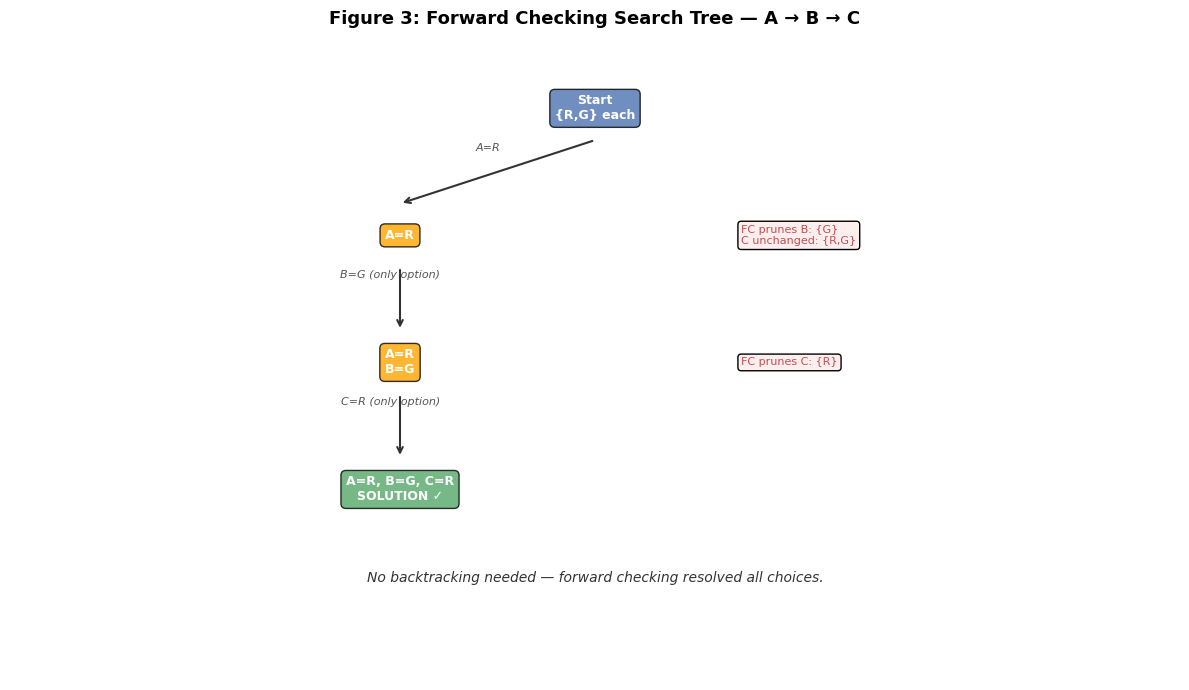

In [128]:
# ── Visualisation: Search tree for forward checking ──

fig, ax = plt.subplots(figsize=(12, 7))
ax.set_xlim(-1, 11)
ax.set_ylim(-0.5, 4.5)
ax.axis('off')
ax.set_title('Figure 3: Forward Checking Search Tree — A → B → C',
             fontsize=13, fontweight='bold', pad=15)

# Node positions (manually laid out for clarity)
nodes = {
    'root':     (5, 4),
    'A=R':      (3, 3),
    'A=G':      (7, 3),
    'A=R,B=G':  (3, 2),
    'A=R,B=G,C=R': (3, 1),
}

# Draw edges
edges = [
    ('root', 'A=R', 'A=R'),
    ('A=R', 'A=R,B=G', 'B=G (only option)'),
    ('A=R,B=G', 'A=R,B=G,C=R', 'C=R (only option)'),
]

for parent, child, label in edges:
    px, py = nodes[parent]
    cx, cy = nodes[child]
    ax.annotate('', xy=(cx, cy + 0.25), xytext=(px, py - 0.25),
                arrowprops=dict(arrowstyle='->', lw=1.5, color='#333333'))
    mx, my = (px + cx) / 2, (py + cy) / 2
    ax.text(mx - 0.1, my + 0.15, label, fontsize=8, color='#555555',
            ha='center', va='bottom', style='italic')

# Draw nodes
for name, (x, y) in nodes.items():
    if name == 'root':
        color = '#4C72B0'
        text = 'Start\n{R,G} each'
    elif 'C=R' in name:
        color = '#55A868'
        text = 'A=R, B=G, C=R\nSOLUTION ✓'
    else:
        color = '#FFA500'
        text = name.replace(',', '\n')

    bbox = dict(boxstyle='round,pad=0.4', facecolor=color, alpha=0.8)
    ax.text(x, y, text, fontsize=9, ha='center', va='center',
            bbox=bbox, color='white', fontweight='bold')

# Annotation: domains at each level
ax.text(6.5, 3, 'FC prunes B: {G}\nC unchanged: {R,G}',
        fontsize=8, color='#C44E52', ha='left', va='center',
        bbox=dict(boxstyle='round', facecolor='#FFEEEE'))
ax.text(6.5, 2, 'FC prunes C: {R}',
        fontsize=8, color='#C44E52', ha='left', va='center',
        bbox=dict(boxstyle='round', facecolor='#FFEEEE'))

ax.text(5, 0.3, 'No backtracking needed — forward checking resolved all choices.',
        fontsize=10, ha='center', va='center', style='italic', color='#333333')

plt.tight_layout()
plt.show()

### Summary of Forward Checking Trace

The table below provides the concise step-by-step trace requested in the problem:

| Step | Assignment | Domains After Forward Checking | Action |
|------|------------|-------------------------------|--------|
| 1 | A = R | A: {R}, B: {G}, C: {R, G} | Continue |
| 2 | A = R, B = G | A: {R}, B: {G}, C: {R} | Continue |
| 3 | A = R, B = G, C = R | A: {R}, B: {G}, C: {R} | **Solution found** |

Forward checking eliminated the need for any backtracking by pruning inconsistent values immediately after each assignment. When A was set to R, the constraint A ≠ B removed R from B's domain, leaving only G. When B was set to G, the constraint B ≠ C removed G from C's domain, leaving only R. The algorithm thus found the solution (R, G, R) in three steps without ever needing to undo an assignment.

**When would backtracking be triggered?** The problem above is loosely constrained — a path graph with two colors always admits a valid coloring. However, suppose we added a third constraint **A ≠ C** (turning the path into a triangle/cycle). After assigning A = R and propagating, B's domain would reduce to {G} (from A ≠ B) and C's domain would reduce to {G} (from A ≠ C). Assigning B = G and propagating B ≠ C would then wipe out C's domain entirely: {G} \ {G} = **∅**. An empty domain signals a **domain wipeout (DWO)**, causing forward checking to *backtrack* — the algorithm would undo A = R, try A = G instead, and continue the search. In general, backtracking is triggered whenever forward checking detects that some future variable's domain has been emptied by the current assignment, meaning no consistent completion is possible along that branch (Russell & Norvig, 2021). This early detection is precisely the advantage of forward checking over naive backtracking, which would not discover the inconsistency until it attempted to assign the empty-domain variable directly.

---
## References

Dechter, R. (2003). *Constraint processing*. Morgan Kaufmann. https://doi.org/10.1016/B978-1-55860-890-0.X5000-2

Kumar, V. (1992). Algorithms for constraint-satisfaction problems: A survey. *AI Magazine*, *13*(1), 32–44. https://doi.org/10.1609/aimag.v13i1.976

Mackworth, A. K. (1977). Consistency in networks of relations. *Artificial Intelligence*, *8*(1), 99–118. https://doi.org/10.1016/0004-3702(77)90007-8

Norvig, P. (2006). Solving every Sudoku puzzle. https://norvig.com/sudoku.html

Russell, S., & Norvig, P. (2021). *Artificial intelligence: A modern approach* (4th ed.). Pearson. https://aima.cs.berkeley.edu/

Yue, T.-W., & Chen, M.-C. (2004). Q'tron neural networks for constraint satisfaction. In *Proceedings of the Fourth International Conference on Hybrid Intelligent Systems (HIS'04)* (pp. 398–403). IEEE. https://doi.org/10.1109/ICHIS.2004.77